# Projet EDP 


### Thomas BERBESSOU 
### Émile De Vos
### B1

In [1]:
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import numpy as np
import scipy.sparse as scps
import scipy.sparse.linalg as ssl
import math

In [2]:
def maillage(n):
#
# Une discretisation possible d'une EDP elliptique sur le domaine ]0,1[ x ]0,1[
# Le carre [0,1]x[0,1] est maille uniquement avec des triangles; 
# Les conditions limites sont de type Dirichlet uniquement   => neumann  =[];
#
# Entrees :
# n : nombre de points par cote du care => Npts points de discretisation au
# total
#
# Sorties :
# coordinates : matrice a deux colonnes. Chaque ligne contient les 
# coordonnes 2D d'un des points de la discretisation. Ces sommets seront 
# identifies a l'indice de la ligne correspondante dans la matrice
# coordinates.
# elements3 : matrice a trois colonnes. Chaque ligne contient les indices 
# des sommets d'un element triangle, dans le sens antihoraire. 
# dirichlet : vecteur colonne des indices des sommets de la frontiere de
# Dirichlet.
# neumann : matrice a deux colonnes. Chaque ligne contient les indices 
# des deux sommets d'une arete de la frontiere de Neumann.
# (neumann est vide sur cet exemple)
#
######################################################uadrangle T############################
    h=1/(n-1)
    npoin       = n*n ; 
    nelem = 2*(n-1)*(n-1) 
    coordinates = np.zeros((npoin,2))
    elements3   = (np.zeros((nelem,3))).astype(int) 
    neumann     = []
    dirichlet=(np.zeros((4*n-4,1))).astype(int)
    # Coordonnees et connectivites :
    e = -1 
    p = -1 
    x=np.zeros((n+1,1))
    x[n,0]=1.
    for l in range (n+1):
        x[l,0]=l*h
    for j in range (n):
            for i in range(n):
                p = p + 1  
                coordinates[p,0] = x[i,0]  
                coordinates[p,1] = x[j,0] 
                if ((i != n-1) & (j != n-1)):
                    p1 = p
                    p2 = p1 + 1 
                    p3 = p1 + n 
                    p4 = p2 + n 
                    e = e + 1 
                    elements3[e,0] = p1 
                    elements3[e,1] = p2 
                    elements3[e,2] = p3 
                    e = e + 1
                    elements3[e,0] = p4 
                    elements3[e,1] = p3 
                    elements3[e,2] = p2 
    #Liste des sommets de la frontiere de Dirichlet:
    p=-1
    for j in range(n):
        p=p+1
        dirichlet[p,0] = j  
    for j in range(n*2-1,n*(n-1),n):
        p=p+1
        dirichlet[p,0] = j 
    for j in range(n*n-1,n*n-n-1,-1):
        p=p+1
        dirichlet[p,0] = j 
    for j in range(n*n-2*n,n-1,-n):
        p=p+1
        dirichlet[p,0] = j 

    return coordinates, elements3,dirichlet, neumann

In [3]:
def show(coordinates,u):
#
# Fonction d'affichage de la solution u sur le maillage defini par
# elements Les conditions limites sont de type Dirichlet uniquement   => neumann  =[];
#
# Entrees :
# elements3 : matrice a trois colonnes. Chaque ligne co: Les conditions 
#             limites sont de type Dirichlet uniquement   => neumann  =[];
#
# Entrees :
# n : nombre de points par cote du care => Npts points de discretisation au
# total
#
# Sorties :(s[(jj + 1)%3, 1]-s[(jj + 2)%3, 1])*(s[(ii + 1)%3, 1]-s[(ii + 2)%3, 1])
# coordinates : matrice a deux colonnes. Chaque ligne contient les 
# coordonnes 2D d'un des points de la discretisation. Ces sommets seront 
# identifies a l'indice de la ligne correspondante dans la matrice
# coordinates.
# elements3 : matrice a trois colonnes. Chaque ligne co
# sommets.
# coordinates : matrice a deux colonnes contenant les coordonnes 2D des
# points de la discretisation.A = np.zeros([100,100])
    
    ax = plt.figure().add_subplot(projection='3d')
    ax.plot_trisurf(coordinates[:,0],coordinates[:,1],u,linewidth=0.2,antialiased=True)
    plt.show()

**Partie I : maillage triangulaire et conditions de Dirichlet**

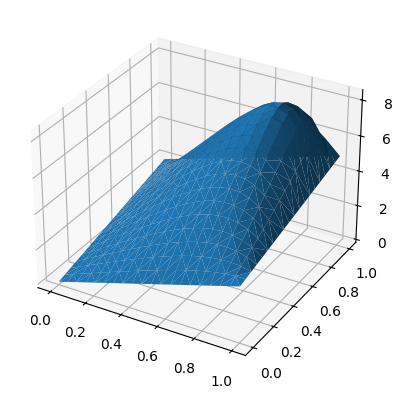

In [4]:
n = 20
coordonnees, elements, dirichlet, neumann = maillage(n)
f = lambda x,y : np.exp(5*(x+y)) #30*np.cos(np.pi*(x+y)) 
ud = lambda x,y : 3*x+2*y
Mt = np.zeros([3,3])
A = np.zeros([n*n,n*n])
b = np.zeros([n*n,1])
Ud=np.zeros([n*n,1])
for p in range(np.size(elements, 0)):
    Triangle_p = elements[p,:]
    s = coordonnees[Triangle_p , :]
    alpha = np.linalg.det( np.array([[s[1,0]-s[0,0], s[2,0]-s[0,0]], [s[1,1]-s[0,1], s[2,1]-s[0,1]]]) )
    for ii in range(3):
        for jj in range(ii, 3): 
            Mt[ii,jj] = Mt[jj,ii] = 1/(2*alpha) * ( (s[(jj + 1)%3, 1]-s[(jj + 2)%3, 1])*(s[(ii + 1)%3, 1]-s[(ii + 2)%3, 1]) +  (s[(jj + 2)%3, 0]-s[(jj + 1)%3, 0])*(s[(ii + 2)%3, 0]-s[(ii + 1)%3, 0]) )
    #mise a jour de A
    for i in range(3):
        for j in range(3):
            A[Triangle_p[i],Triangle_p[j]] += Mt[i,j]
    #mise a jour de b
    xg,yg = np.sum(coordonnees[Triangle_p][0])/3,np.sum(coordonnees[Triangle_p][1])/3

    b[list(Triangle_p),:] += [[alpha/6 *f(xg,yg)],[alpha/6 * f(xg,yg)],[alpha/6 * f(xg,yg)]]

#creation du vercteur Ud
for k in dirichlet:

    i=k[0]
    Ud[i] = ud(coordonnees[i][0],coordonnees[i][1])

#DirichletA non-homogene
b = b - A@Ud

#Initialisation de Uh
Uh = Ud[:,:]
#Recherche des sommets pas sur la frontiere
ind = np.setdiff1d(range(n*n), dirichlet)

z = np.linalg.solve(A[ind,:][:,ind], b[ind])

Uh[ind] = z
show(coordonnees,Uh[:,0])



**Partie II : maillage mixte et ajoût des conditions de Neumann**

In [5]:
############################# Maillage mixte ################
e3=np.array([[1,2,12],[2,3,12],[3,4,14],[4,5,14],[2,15,3],[3,15,4]]).astype(int)
e4=np.array([[0,1,12,11],[11,12,13,10],[12,3,14,13],[10,13,8,9],[13,14,7,8],[14,5,6,7]]).astype(int)
dds=np.array([2,15,4,6,7,8,9,10,11,0]).astype(int)
nns=np.array([[4,5],[5,6],[0,1],[1,2]]).astype(int)
ccs=np.array([[0.,0.],[0.33333333333333,0],[0.53333333333333,0.],
                      [0.66666666666667,0.33333333333333],[1.,0.47],[1,0.66666666666667],
                     [1.,1.],[0.66666666666667,1.],[0.33333333333333,1.], [0.,1.],
                     [0.,0.66666666666667],[0.,0.33333333333333],[0.33333333333333,0.33333333333333],
                     [0.33333333333333,0.66666666666667],[0.66666666666667,0.66666666666667],[1.,0.]])

In [6]:
def construire_M(a,b,c) :
    m = np.array([[2*a + 3*b + 2*c, -2*a+c, -a-3*b-c, a-2*c], 
         [0, 2*a-3*b+2*c, a-2*c, -a+3*b-c],
         [0,0, 2*a+3*b+2*c, -2*a+c],
         [0,0,0,2*a-3*b+2*c]])
    for i in range(1,4):
        for j in range(i):
            m[i,j] = m[j,i]
    return m

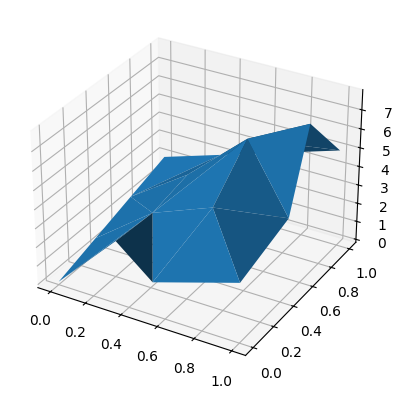

In [12]:
coordonnees, elementsT, elementsQ, dirichlet, neumann = ccs, e3, e4, dds, nns
n = int(np.sqrt(len(coordonnees)))

f = lambda x,y :  np.exp(5*(x+y)) #30*np.cos(np.pi*(x+y)) 
ud = lambda x,y : 3*x+2*y
g = lambda x,y  : 10


A = np.zeros([n*n,n*n])
b = np.zeros([n*n,1])
Ud=np.zeros([n*n,1])
#mise a jour de A et b sur les quadrangles
for q in range(np.size(elementsQ, 0)):
    Quadrangle_p = elementsQ[q,:]
    s = coordonnees[Quadrangle_p , :]
    J = np.array([[s[1,0] - s[0,0], s[3,0]-s[0,0]], [s[1,1]-s[0,1], s[3,1]-s[0,1]]])
    alpha = np.linalg.det( J)
    Jc = np.linalg.inv(np.transpose(J)@J)
    a = Jc[0,0]
    d = Jc[0,1]
    c = Jc[1,1]
    Mq = (np.linalg.det(J)/6) * construire_M(a,d,c)
    #mise a jour de A
    for i in range(4):
        for j in range(4):
            A[Quadrangle_p[i],Quadrangle_p[j]] += Mq[i,j]
    #mise a jour de b
    xg,yg = np.sum(coordonnees[Quadrangle_p][0])/4,np.sum(coordonnees[Quadrangle_p][1])/4

    b[list(Quadrangle_p),:] += [[alpha/4 *f(xg,yg)],[alpha/4 * f(xg,yg)],[alpha/4 * f(xg,yg)], [alpha/4 * f(xg,yg)]]

#mise a jour de a et b sur les triangles
for p in range(np.size(elementsT, 0)):
    Triangle_p = elementsT[p,:]
    s = coordonnees[Triangle_p , :]
    alpha = np.linalg.det( np.array([[s[1,0]-s[0,0], s[2,0]-s[0,0]], [s[1,1]-s[0,1], s[2,1]-s[0,1]]]))
    for ii in range(3):
        for jj in range(ii, 3): 
            Mt[ii,jj] = Mt[jj,ii] = 1/(2*alpha) * ( (s[(jj + 1)%3, 1]-s[(jj + 2)%3, 1])*(s[(ii + 1)%3, 1]-s[(ii + 2)%3, 1]) +  (s[(jj + 2)%3, 0]-s[(jj + 1)%3, 0])*(s[(ii + 2)%3, 0]-s[(ii + 1)%3, 0]) )
    #mise a jour de A
    for i in range(3):
        for j in range(3):
            A[Triangle_p[i],Triangle_p[j]] += Mt[i,j]
    #mise a jour de b
    xg,yg = np.sum(coordonnees[Triangle_p][0])/3,np.sum(coordonnees[Triangle_p][1])/3
   
    b[list(Triangle_p),:] += [[alpha/6 *f(xg,yg)],[alpha/6 * f(xg,yg)],[alpha/6 * f(xg,yg)]]
    
#creation du vercteur Ud
for k in dirichlet:
    Ud[k] = ud(coordonnees[k][0],coordonnees[k][1])

#DirichletA non-homogene
b = b - A@Ud

#boucle sur arrete de neuman,
for p in neumann:
    xg,yg = np.sum(coordonnees[p][0])/2, np.sum(coordonnees[p][1])/2
    inter = (np.linalg.norm(coordonnees[p[0]]-coordonnees[p[1]]))/2*g(xg,yg)
    b[p] += [[inter],[inter]]

#Initialisation de Uh
Uh = Ud[:,:]
#Recherche des sommets pas sur la frontiere
ind = np.setdiff1d(range(n*n), dirichlet)

z = np.linalg.solve(A[ind,:][:,ind], b[ind])

Uh[ind] = z
show(coordonnees,Uh[:,0])


**Compléments  :  un nouveau terme dans l'EDP**

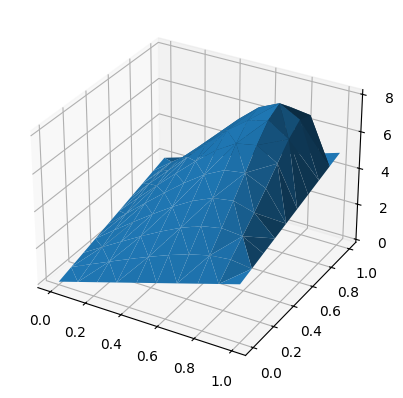

In [11]:
n = 10
coordonnees, elements, dirichlet, neumann = maillage(n)
f = lambda x,y : np.exp(5*(x+y)) #30*np.cos(np.pi*(x+y)) 
ud = lambda x,y : 3*x+2*y
c0 = 1

Mt = np.zeros([3,3])
A = np.zeros([n*n,n*n])
b = np.zeros([n*n,1])
Ud=np.zeros([n*n,1])
for p in range(np.size(elements, 0)):
    Triangle_p = elements[p,:]
    s = coordonnees[Triangle_p , :]
    alpha = np.linalg.det(np.array([[s[1,0]-s[0,0], s[2,0]-s[0,0]], [s[1,1]-s[0,1], s[2,1]-s[0,1]]]))
    for ii in range(3):
        for jj in range(ii, 3): 
            Mt[ii,jj] = Mt[jj,ii] = 1/(2*alpha) * ( (s[(jj + 1)%3, 1]-s[(jj + 2)%3, 1])*(s[(ii + 1)%3, 1]-s[(ii + 2)%3, 1]) +  (s[(jj + 2)%3, 0]-s[(jj + 1)%3, 0])*(s[(ii + 2)%3, 0]-s[(ii + 1)%3, 0]) )
    Mt = Mt + c0*(alpha/24)*np.array([[2,1,1],[1,2,1],[1,1,2]])
    #mise a jour de A
    for i in range(3):
        for j in range(3):
            A[Triangle_p[i],Triangle_p[j]] += Mt[i,j]
    
    #mise a jour de b
    xg,yg = np.sum(coordonnees[Triangle_p][0])/3,np.sum(coordonnees[Triangle_p][1])/3

    b[list(Triangle_p),:] += [[alpha/6 *f(xg,yg)],[alpha/6 * f(xg,yg)],[alpha/6 * f(xg,yg)]]

#creation du vercteur Ud
for k in dirichlet:

    i=k[0]
    Ud[i] = ud(coordonnees[i][0],coordonnees[i][1])

#DirichletA non-homogene
b = b - A@Ud

#Initialisation de Uh
Uh = Ud[:,:]
#Recherche des sommets pas sur la frontiere
ind = np.setdiff1d(range(n*n), dirichlet)

z = np.linalg.solve(A[ind,:][:,ind], b[ind])

Uh[ind] = z
show(coordonnees,Uh[:,0])